# Punto 8 — Revisión de los errores del modelo

Un **residuo** es la diferencia entre un dato observado y el valor que el modelo esperaba para ese día. Un modelo adecuado debería dejar errores sin patrones claros.

Se revisan los modelos del punto 5 con el entrenamiento 2023–2024. Se descartan las primeras 30 predicciones disponibles, o más si lo requiere la inicialización. En temperatura, la diferencia anual también elimina los primeros 365 días.

Se presentan el gráfico de residuos, su autocorrelación (FAC), un histograma y un gráfico Q–Q. Este último compara la forma de los errores con una distribución normal.

**Ljung–Box** evalúa si queda relación entre errores separados por varios días. La hipótesis inicial es que no hay autocorrelación hasta el rezago indicado. Un p-valor menor a 0,05 sugiere que el modelo dejó un patrón sin explicar. Se descuentan los parámetros AR y MA, incluidos los estacionales.

También se usan **Jarque–Bera**, para revisar normalidad, y **ARCH-LM**, para revisar si el tamaño de los errores depende de errores anteriores. No rechazar una prueba no demuestra que su supuesto sea verdadero. Los p-valores son orientativos: se realizan varias pruebas sobre los mismos datos.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data/bicicletas_rosario.csv').exists())
if str(ROOT/'scripts') not in sys.path: sys.path.insert(0,str(ROOT/'scripts'))
from modelos_puntos56 import cargar, ajustar, ajustados, pronosticar, metricas, etiqueta
from modelos_resto import *
series=cargar(ROOT)
seleccion=json.loads((ROOT/'puntos/punto5/seleccion.json').read_text())
plt.rcParams.update({'figure.figsize':(11,4),'figure.dpi':120})


/usr/local/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


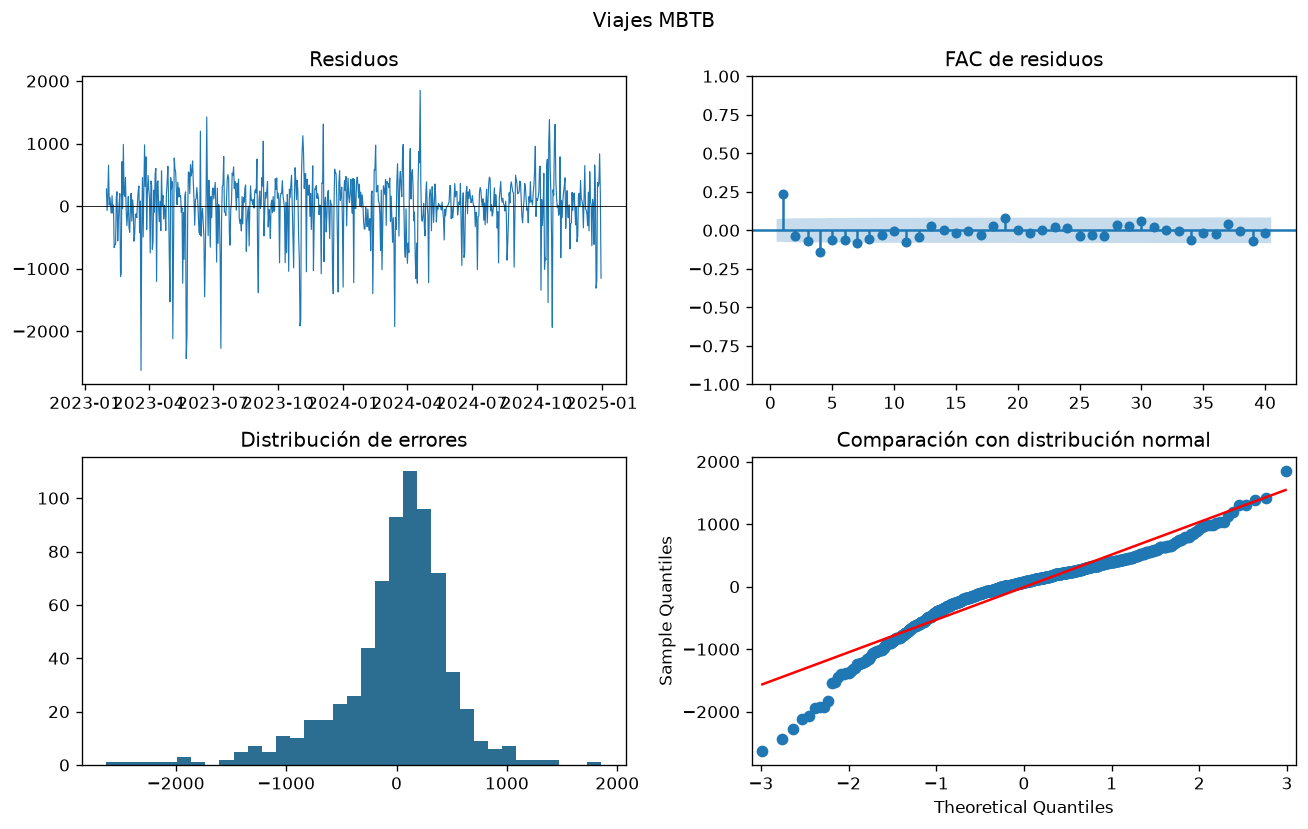

/usr/local/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


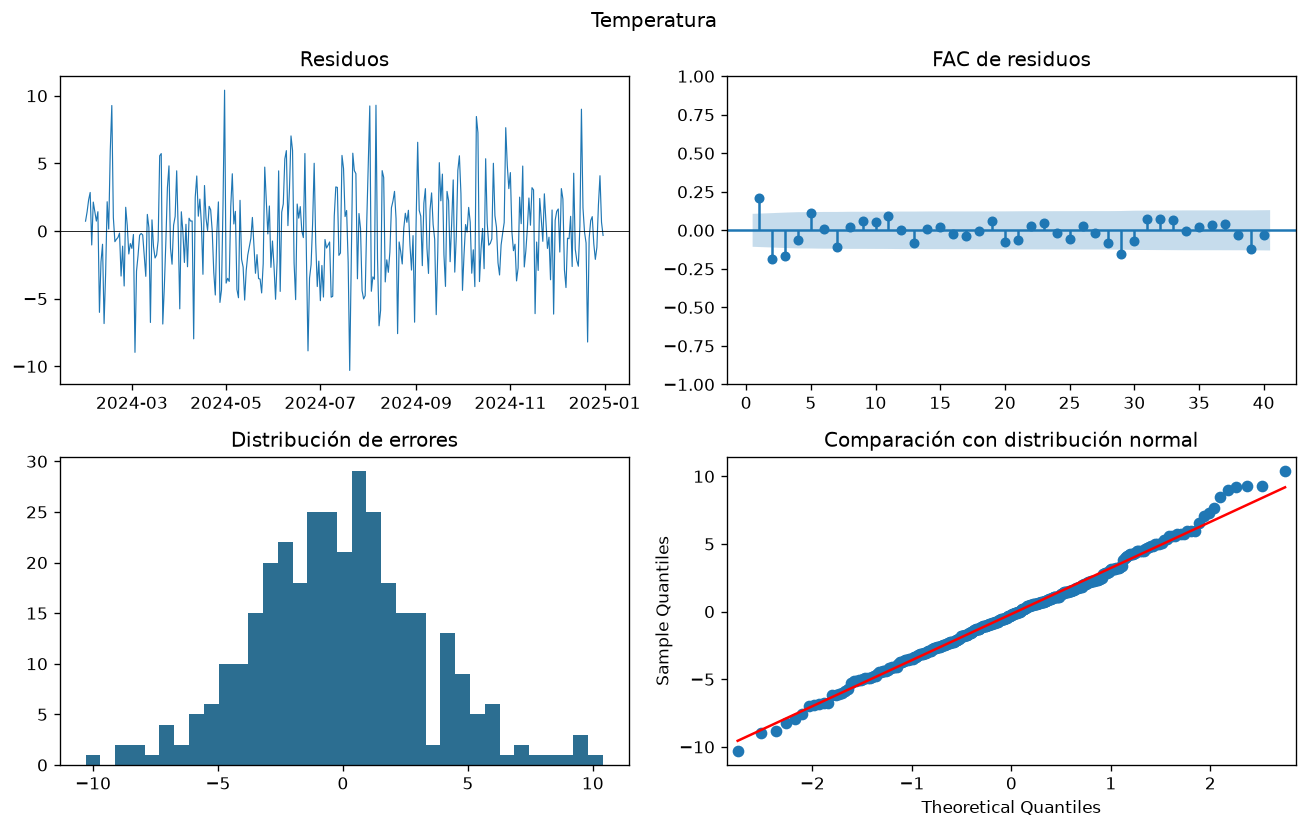

/usr/local/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


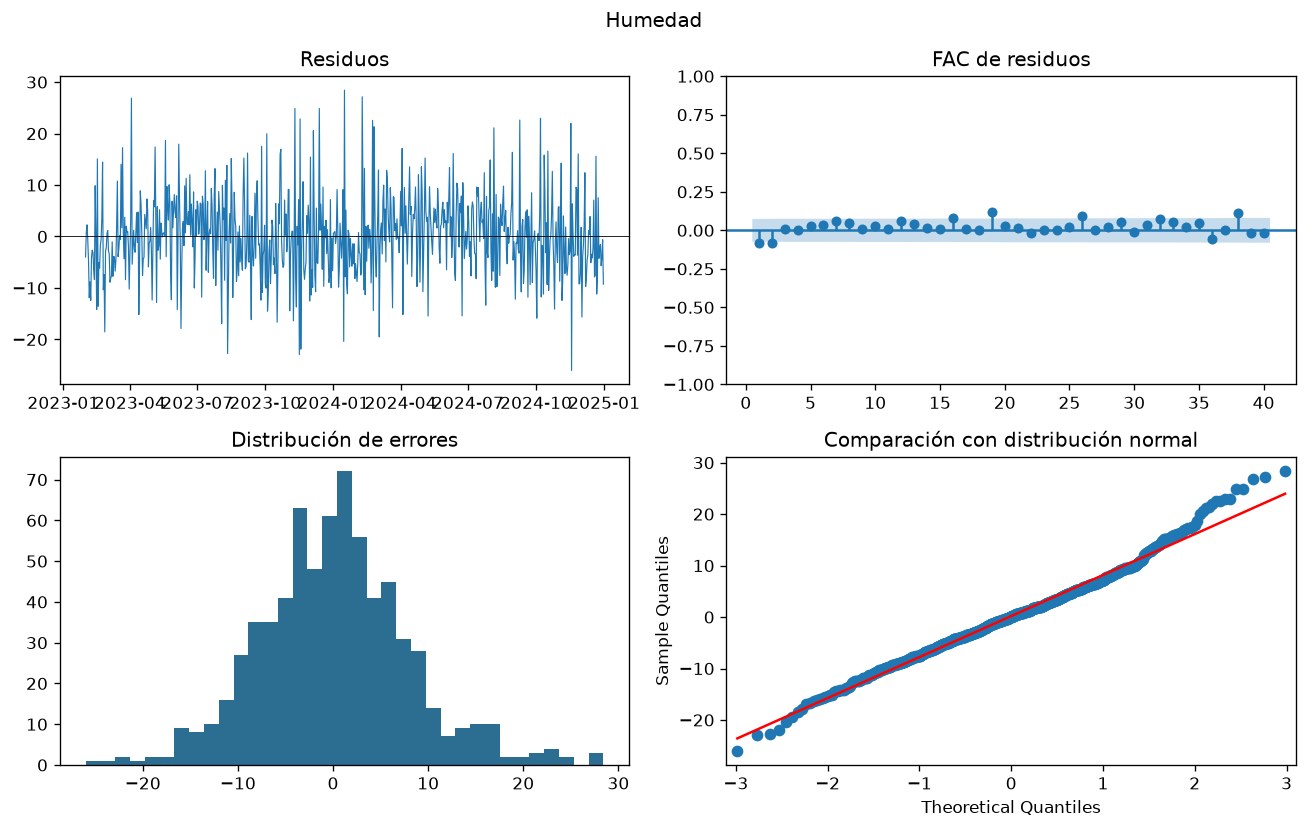

/usr/local/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


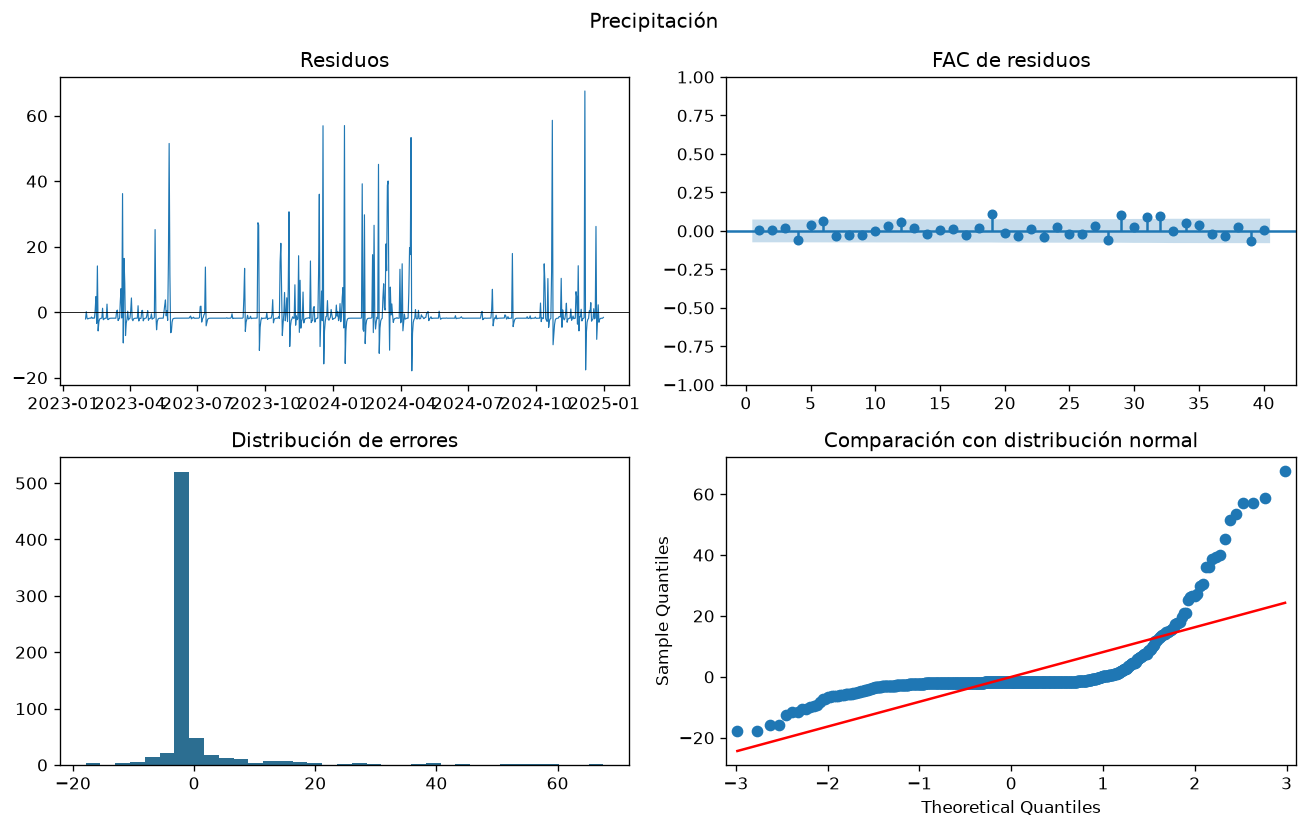

,lb_stat,lb_pvalue,serie,rezago,rechaza_5pct
0,68.66058,0.00000,Viajes MBTB,7,True
1,77.43480,0.00000,Viajes MBTB,14,True
2,87.51068,0.00000,Viajes MBTB,28,True
3,45.51400,0.00000,Temperatura,7,True
4,53.10409,0.00000,Temperatura,14,True
5,64.32876,0.00007,Temperatura,28,True
6,13.69395,0.03325,Humedad,7,True
7,20.41113,0.08542,Humedad,14,False
8,42.84089,0.02714,Humedad,28,True
9,7.52784,0.18425,Precipitación,7,False


,serie,n,media_error,JB_p,ARCH_p,raiz_minima,parametro_cerca_limite
0,Viajes MBTB,701,-8.56924,0.00000,0.00024,1.00003,True
1,Temperatura,336,-0.18014,0.17007,0.73729,1.30924,False
2,Humedad,701,0.19083,0.00000,0.00222,1.21375,False
3,Precipitación,701,-0.01159,0.00000,0.29427,1.96719,False


**Viajes MBTB:** Queda autocorrelación según Ljung–Box en los rezagos [7, 14, 28]. Los parámetros están cerca del límite de estabilidad o invertibilidad; sus errores estándar requieren cautela. Se rechaza normalidad. ARCH sugiere cambios predecibles en la variabilidad.

**Temperatura:** Queda autocorrelación según Ljung–Box en los rezagos [7, 14, 28]. No se rechaza normalidad. ARCH no detecta ese patrón al 5%.

**Humedad:** Queda autocorrelación según Ljung–Box en los rezagos [7, 28]. Se rechaza normalidad. ARCH sugiere cambios predecibles en la variabilidad.

**Precipitación:** Ljung–Box no detecta autocorrelación al 5% en los rezagos evaluados. Se rechaza normalidad. ARCH no detecta ese patrón al 5%.

In [2]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import jarque_bera
OUT=ROOT/'puntos/punto8';OUT.mkdir(exist_ok=True)
filas=[];residuos=[];otros=[]
for i,(nombre,s) in enumerate(series.items()):
    train=s.loc[:'2024-12-31'];c=seleccion[nombre];r,_=ajustar(train,c)
    pred=ajustados(r,train,c).iloc[max(30,int(r.loglikelihood_burn)):]
    e=train.reindex(pred.index)-pred
    dof=c['order'][0]+c['order'][2]+c['seasonal_order'][0]+c['seasonal_order'][2]
    lb=acorr_ljungbox(e,lags=[7,14,28],model_df=dof,return_df=True)
    lb['serie']=nombre;lb['rezago']=lb.index;lb['rechaza_5pct']=lb.lb_pvalue<.05
    filas.append(lb.reset_index(drop=True))
    jb=jarque_bera(e);arch=het_arch(e,nlags=7,ddof=dof)
    raices=np.concatenate([np.abs(r.arroots),np.abs(r.maroots)])
    otros.append({'serie':nombre,'n':len(e),'media_error':e.mean(),'JB_p':jb.pvalue,'ARCH_p':arch[1],
                  'raiz_minima':raices.min() if len(raices) else np.nan,
                  'parametro_cerca_limite':bool(len(raices) and raices.min()<1.01)})
    residuos.append(pd.DataFrame({'fecha':e.index,'serie':nombre,'residuo':e.values}))
    fig,axes=plt.subplots(2,2,figsize=(11,7))
    axes[0,0].plot(e,lw=.7);axes[0,0].axhline(0,color='black',lw=.5);axes[0,0].set_title('Residuos')
    plot_acf(e,lags=40,zero=False,ax=axes[0,1]);axes[0,1].set_title('FAC de residuos')
    axes[1,0].hist(e,bins=35,color='#2c6e91');axes[1,0].set_title('Distribución de errores')
    qqplot(e,line='s',ax=axes[1,1]);axes[1,1].set_title('Comparación con distribución normal')
    fig.suptitle(nombre);fig.tight_layout();fig.savefig(OUT/f'diagnostico_{i}.png');plt.show();plt.close(fig)
ljung=pd.concat(filas,ignore_index=True);diagnostico=pd.DataFrame(otros)
ljung.to_csv(OUT/'ljung_box.csv',index=False);diagnostico.to_csv(OUT/'diagnostico.csv',index=False)
pd.concat(residuos).to_csv(OUT/'residuos.csv',index=False)
display(ljung.round(5));display(diagnostico.round(5))
for row in diagnostico.itertuples():
    sub=ljung[ljung.serie==row.serie];rechazos=sub.loc[sub.rechaza_5pct,'rezago'].tolist()
    texto=f'Queda autocorrelación según Ljung–Box en los rezagos {rechazos}.' if rechazos else 'Ljung–Box no detecta autocorrelación al 5% en los rezagos evaluados.'
    display(Markdown(f'**{row.serie}:** {texto} '
        + ('Los parámetros están cerca del límite de estabilidad o invertibilidad; sus errores estándar requieren cautela. ' if row.parametro_cerca_limite else '')
        + ('Se rechaza normalidad. ' if row.JB_p<.05 else 'No se rechaza normalidad. ')
        + ('ARCH sugiere cambios predecibles en la variabilidad.' if row.ARCH_p<.05 else 'ARCH no detecta ese patrón al 5%.')))


## Alcance del diagnóstico

Un error promedio pequeño no basta para considerar correcto un modelo. Si quedan autocorrelaciones, puede faltar un ciclo o una relación temporal. Si la normalidad falla, los intervalos gaussianos pueden representar mal los extremos. El diagnóstico puede cuestionar el modelo aunque haya tenido el menor MAE de validación.

**Referencia:** Statsmodels developers. (s. f.). [Prueba de Ljung–Box](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html).